【兩個原子相距很遠：幾乎沒有能階分裂】

In [248]:
import numpy as np
import matplotlib.pyplot as plt

In [249]:
# 設定參數
L = 10              # 空間範圍 [-L, L]
Nx = 2000           # 空間點數
x = np.linspace(-L, L, Nx)
dx = x[1] - x[0]

# 雙井參數
d = 4.0             # 井間距（先設大一點）
V0 = -50            # 位勢井深（負值表吸引井）
sigma = 0.5         # 位勢井寬

In [250]:
# 建立雙井位能（兩個高斯井）
def V(x):
    left = V0 * np.exp(-(x + d/2)**2 / (2*sigma**2))
    right = V0 * np.exp(-(x - d/2)**2 / (2*sigma**2))
    return left + right

Vx = V(x)

# 建立 kinetic term（有限差分）
diag = np.ones(Nx)
offdiag = np.ones(Nx-1)

T = (-1/(2*dx**2)) * (
    np.diag(-2*diag) +
    np.diag(offdiag, 1) +
    np.diag(offdiag, -1)
)

In [251]:
# Hamiltonian
H = T + np.diag(Vx)

# 求本徵值
eigvals, eigvecs = np.linalg.eigh(H)

# 取最低兩個
E1, E2 = eigvals[0], eigvals[1]
psi1 = eigvecs[:, 0]
psi2 = eigvecs[:, 1]

# normalization（保險）
psi1 = psi1 / np.sqrt(np.sum(np.abs(psi1)**2) * dx)
psi2 = psi2 / np.sqrt(np.sum(np.abs(psi2)**2) * dx)

print(f"E1 = {E1:.8f}, E2 = {E2:.8f}, ΔE = {E2 - E1:.8f}")

E1 = -43.30631001, E2 = -43.30631001, ΔE = 0.00000000


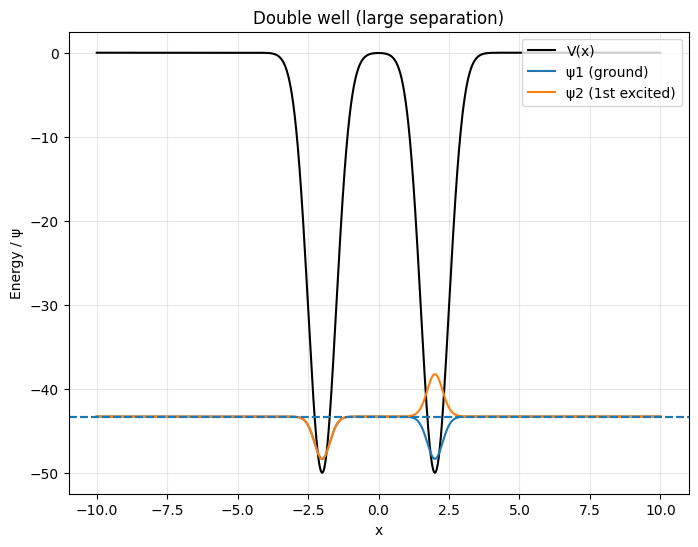

In [252]:
# 畫畫畫畫畫畫圖
plt.figure(figsize=(8,6))

# 位能
plt.plot(x, Vx, color='black', label='V(x)')

# 波函數（稍微縮放讓圖好看）
scale = 5
plt.plot(x, psi1*scale + E1, label='ψ1 (ground)')
plt.plot(x, psi2*scale + E2, label='ψ2 (1st excited)')

# 能量線
plt.axhline(E1, linestyle='--')
plt.axhline(E2, linestyle='--')

plt.legend(loc='upper right')
plt.xlabel("x")
plt.ylabel("Energy / ψ")
plt.title("Double well (large separation)")
plt.grid(alpha=0.3)
plt.show()

– 為什麼 E1 與 E2 很接近？ 

– 這兩個態比較像兩個幾乎互不干擾的原子，還是一個真正形成的分子？

ANS:

1.因為兩個位能井距離很遠，波函數幾乎不重疊，因此幾乎沒有遂穿或耦合，導致最低兩個本徵能量簡併，因此兩位能井的能量幾乎一致。

2.兩個幾乎互不干擾的原子。因為電子幾乎不會在兩井之間移動，沒有形成具有能階分裂的分子態。

【兩個原子慢慢靠近】

In [253]:
# 雙井參數
d_iv = 1.2           # 井間距（自變數）
V0 = -50            
sigma = 0.5         

In [254]:
# 建立雙井位能（兩個高斯井）
def V(x):
    left = V0 * np.exp(-(x + d_iv/2)**2 / (2*sigma**2))
    right = V0 * np.exp(-(x - d_iv/2)**2 / (2*sigma**2))
    return left + right

Vx = V(x)

# 建立 kinetic term（有限差分）
diag = np.ones(Nx)
offdiag = np.ones(Nx-1)

T = (-1/(2*dx**2)) * (
    np.diag(-2*diag) +
    np.diag(offdiag, 1) +
    np.diag(offdiag, -1)
)

In [255]:
# Hamiltonian
H = T + np.diag(Vx)

# 求本徵值
eigvals, eigvecs = np.linalg.eigh(H)

# 取最低兩個
E1, E2 = eigvals[0], eigvals[1]
psi1 = eigvecs[:, 0]
psi2 = eigvecs[:, 1]

# normalization（保險）
psi1 = psi1 / np.sqrt(np.sum(np.abs(psi1)**2) * dx)
psi2 = psi2 / np.sqrt(np.sum(np.abs(psi2)**2) * dx)

# 機率密度
density1 = np.abs(psi1)**2
density2 = np.abs(psi2)**2

print(f"E1 = {E1:.8f}, E2 = {E2:.8f}, ΔE = {E2 - E1:.8f}")

E1 = -49.97953746, E2 = -47.45485435, ΔE = 2.52468311


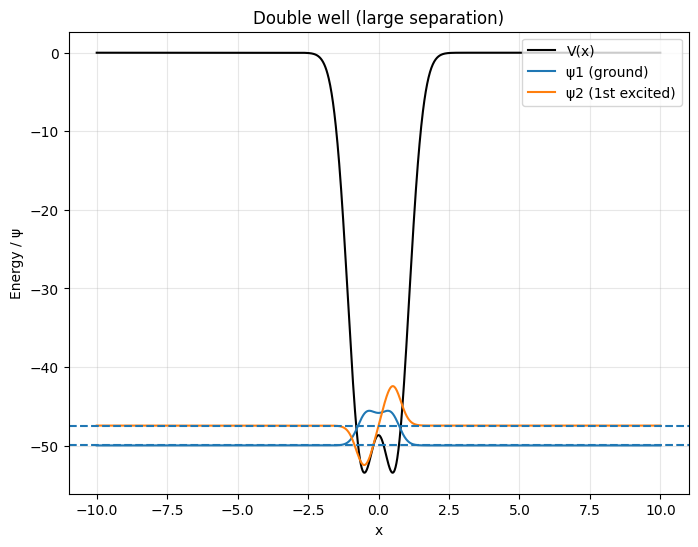

In [256]:
# 畫畫畫畫畫畫圖
plt.figure(figsize=(8,6))

# 位能
plt.plot(x, Vx, color='black', label='V(x)')

# 波函數（稍微縮放讓圖好看）
scale = 5
plt.plot(x, psi1*scale + E1, label='ψ1 (ground)')
plt.plot(x, psi2*scale + E2, label='ψ2 (1st excited)')

# 能量線
plt.axhline(E1, linestyle='--')
plt.axhline(E2, linestyle='--')

plt.legend(loc='upper right')
plt.xlabel("x")
plt.ylabel("Energy / ψ")
plt.title("Double well (large separation)")
plt.grid(alpha=0.3)
plt.show()